In [ ]:
# Install XGBoost (Run only once in Colab)
!pip install -q xgboost

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Replace the filename if needed
df = pd.read_csv("telecom_customer_churn.csv")

# Display first 5 rows
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (7043, 38)

Column Names:
Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                         

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


In [ ]:
df.describe(include='all')

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
count,7043,7043,7043.000000,7043,7043.000000,7043,7043.000000,7043.000000,7043.000000,7043.000000,...,7043,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043,1869,1869
unique,7043,2,NaN,2,NaN,1106,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,NaN,NaN,NaN,3,5,20
top,9995-HOTOH,Male,NaN,No,NaN,Los Angeles,NaN,NaN,NaN,NaN,...,Bank Withdrawal,NaN,NaN,NaN,NaN,NaN,NaN,Stayed,Competitor,Competitor had better devices
freq,1,3555,NaN,3641,NaN,293,NaN,NaN,NaN,NaN,...,3909,NaN,NaN,NaN,NaN,NaN,NaN,4720,841,313
mean,NaN,NaN,46.509726,NaN,0.468692,NaN,93486.070567,36.197455,-119.756684,1.951867,...,NaN,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,NaN,NaN,NaN
std,NaN,NaN,16.750352,NaN,0.962802,NaN,1856.767505,2.468929,2.154425,3.001199,...,NaN,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,NaN,NaN,NaN
min,NaN,NaN,19.000000,NaN,0.000000,NaN,90001.000000,32.555828,-124.301372,0.000000,...,NaN,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,NaN,NaN,NaN
25%,NaN,NaN,32.000000,NaN,0.000000,NaN,92101.000000,33.990646,-121.788090,0.000000,...,NaN,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,NaN,NaN,NaN
50%,NaN,NaN,46.000000,NaN,0.000000,NaN,93518.000000,36.205465,-119.595293,0.000000,...,NaN,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,NaN,NaN,NaN
75%,NaN,NaN,60.000000,NaN,0.000000,NaN,95329.000000,38.161321,-117.969795,3.000000,...,NaN,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,NaN,NaN,NaN


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (7043, 38)


In [ ]:
df.sample(10)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
1270,1877-HKBQX,Female,21,No,0,Cerritos,90703,33.868100,-118.067402,0,...,Mailed Check,54.60,617.85,0.00,0,12.76,630.61,Stayed,NaN,NaN
766,1114-CENIM,Male,43,No,2,San Jacinto,92582,33.806708,-117.020070,0,...,Credit Card,55.00,3092.65,0.00,0,361.80,3454.45,Churned,Other,Don't know
2608,3719-TDVQB,Female,68,Yes,0,Ripon,95366,37.750778,-121.132380,3,...,Mailed Check,18.95,1031.10,0.00,0,1292.76,2323.86,Stayed,NaN,NaN
5407,7619-ODSGN,Male,63,Yes,2,Foothill Ranch,92610,33.698728,-117.677680,1,...,Bank Withdrawal,54.75,1338.15,0.00,0,414.48,1752.63,Churned,Attitude,Attitude of support person
5765,8107-RZLNV,Male,22,Yes,0,South Gate,90280,33.944624,-118.192615,10,...,Bank Withdrawal,106.30,7565.35,0.00,0,1086.48,8651.83,Stayed,NaN,NaN
2169,3097-NQYSN,Male,73,Yes,0,San Jose,95139,37.218705,-121.762429,3,...,Credit Card,86.85,156.35,0.00,40,8.38,204.73,Churned,Competitor,Competitor had better devices
6447,9128-CPXKI,Female,36,No,0,Nicolaus,95659,38.788898,-121.608624,0,...,Bank Withdrawal,95.80,5655.45,0.00,0,1795.96,7451.41,Stayed,NaN,NaN
1144,1685-BQULA,Female,54,No,0,La Quinta,92253,33.695532,-116.310571,0,...,Bank Withdrawal,93.40,3756.40,4.18,0,113.20,3865.42,Stayed,NaN,NaN
6583,9360-AHGNL,Female,74,Yes,0,Concord,94519,37.990118,-122.012188,7,...,Credit Card,109.55,4830.25,0.00,0,376.25,5206.50,Churned,Dissatisfaction,Limited range of services
3617,5130-YPIRV,Female,22,Yes,0,San Diego,92119,32.802959,-117.027095,1,...,Credit Card,72.00,4284.20,0.00,0,397.42,4681.62,Stayed,NaN,NaN


In [ ]:
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print("Visualization Settings Applied!")

Visualization Settings Applied!


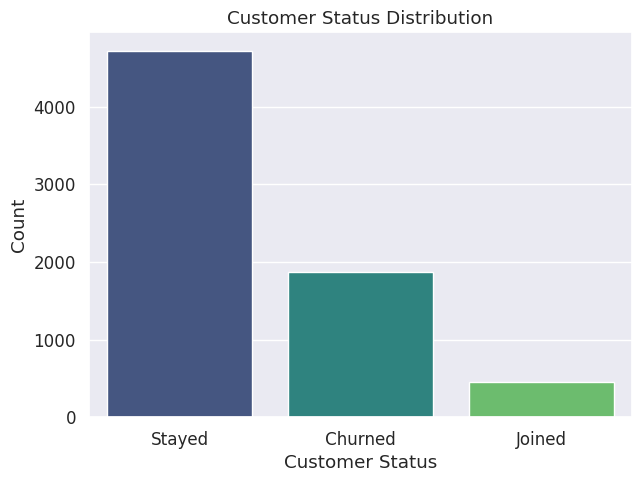

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x=df['Customer Status'], palette='viridis')

plt.title("Customer Status Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Count")

plt.show()

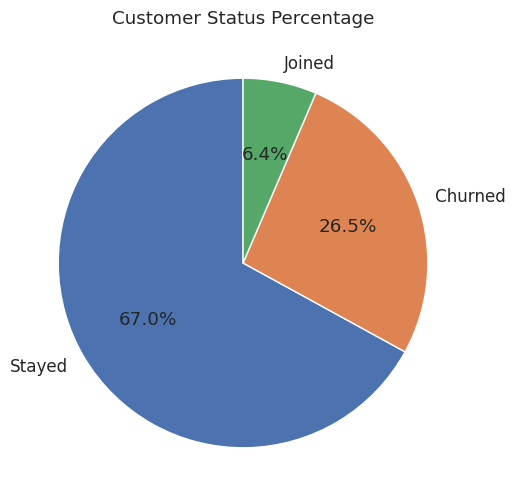

In [ ]:
status = df['Customer Status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(status,
        labels=status.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Status Percentage")

plt.show()

plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df, palette='Set2')

plt.title("Gender Distribution")

plt.show()

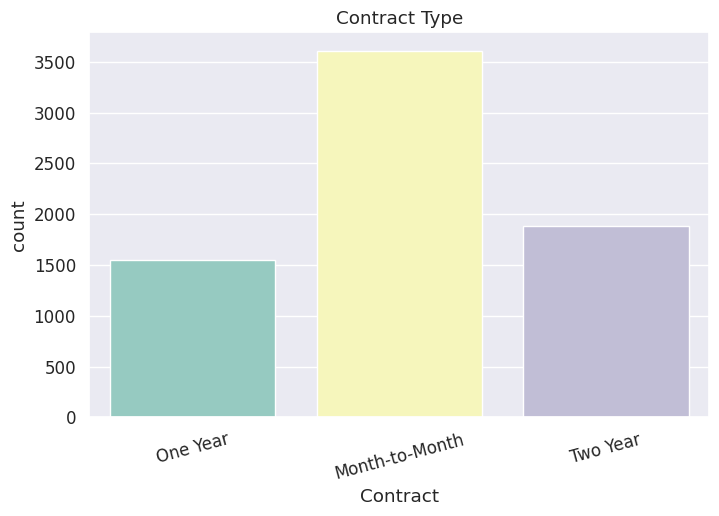

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',
              data=df,
              palette='Set3')

plt.title("Contract Type")

plt.xticks(rotation=15)

plt.show()

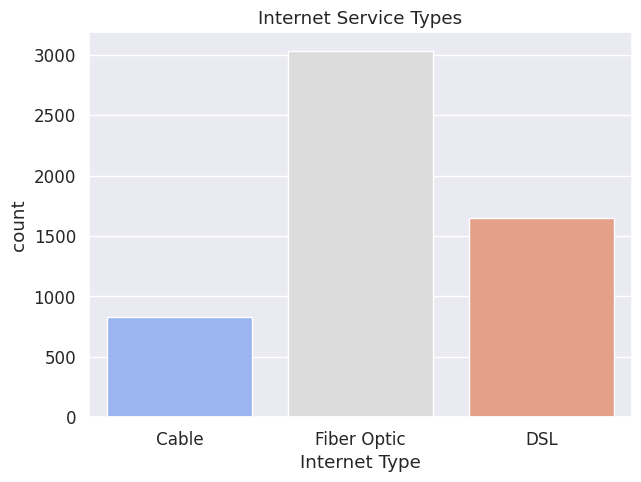

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='Internet Type',
              data=df,
              palette='coolwarm')

plt.title("Internet Service Types")

plt.show()

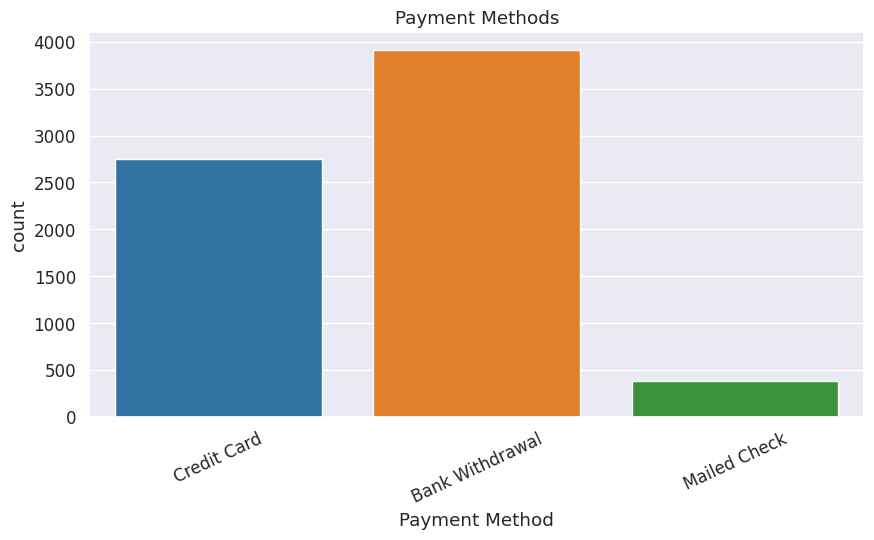

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='Payment Method',
              data=df,
              palette='tab10')

plt.xticks(rotation=25)

plt.title("Payment Methods")

plt.show()

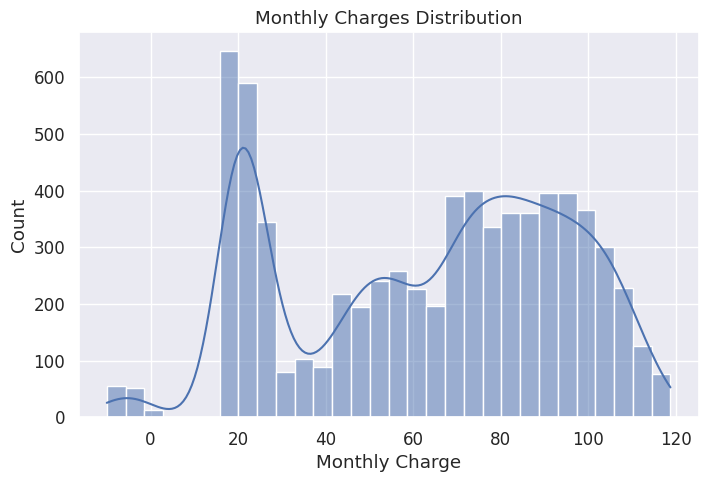

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Monthly Charge'],
             bins=30,
             kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

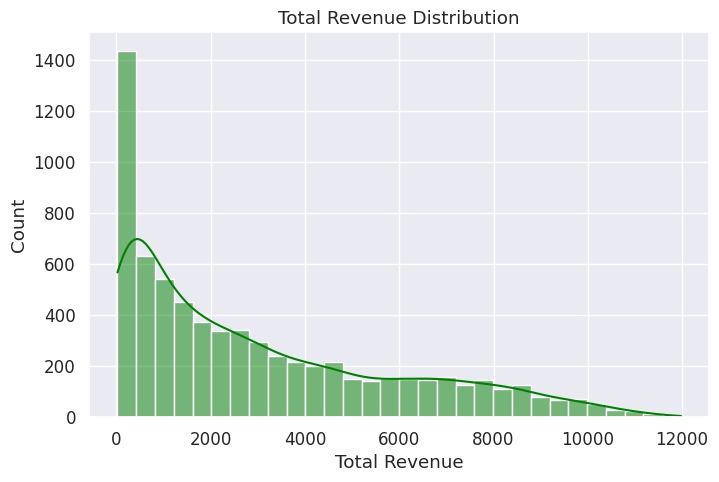

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Revenue'],
             bins=30,
             kde=True,
             color='green')

plt.title("Total Revenue Distribution")

plt.show()

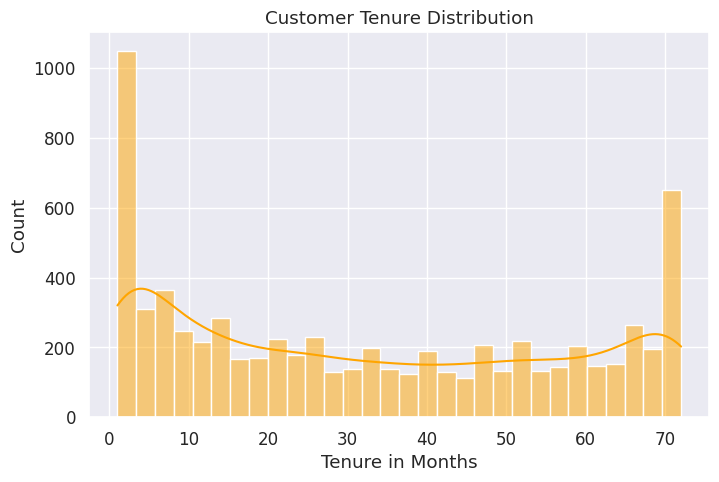

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Tenure in Months'],
             bins=30,
             kde=True,
             color='orange')

plt.title("Customer Tenure Distribution")

plt.show()

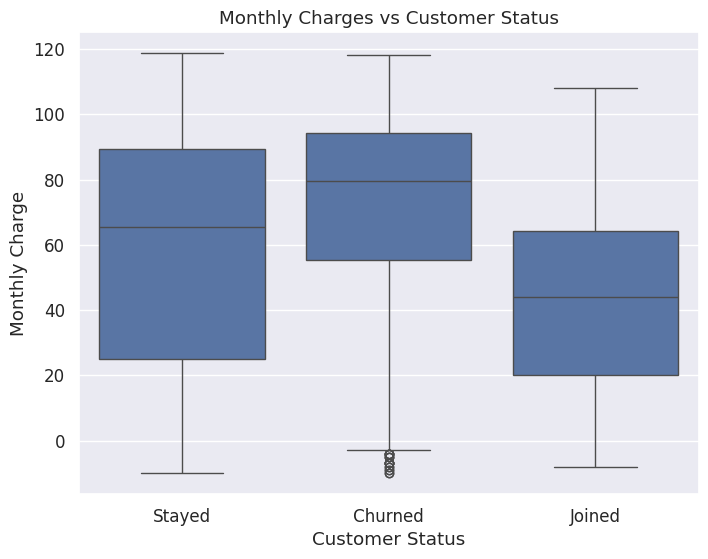

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Customer Status',
            y='Monthly Charge',
            data=df)

plt.title("Monthly Charges vs Customer Status")

plt.show()

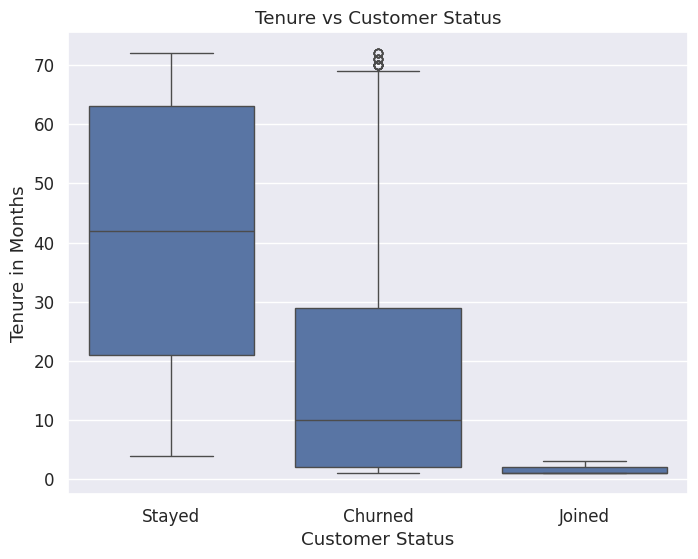

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x='Customer Status',
            y='Tenure in Months',
            data=df)

plt.title("Tenure vs Customer Status")

plt.show()

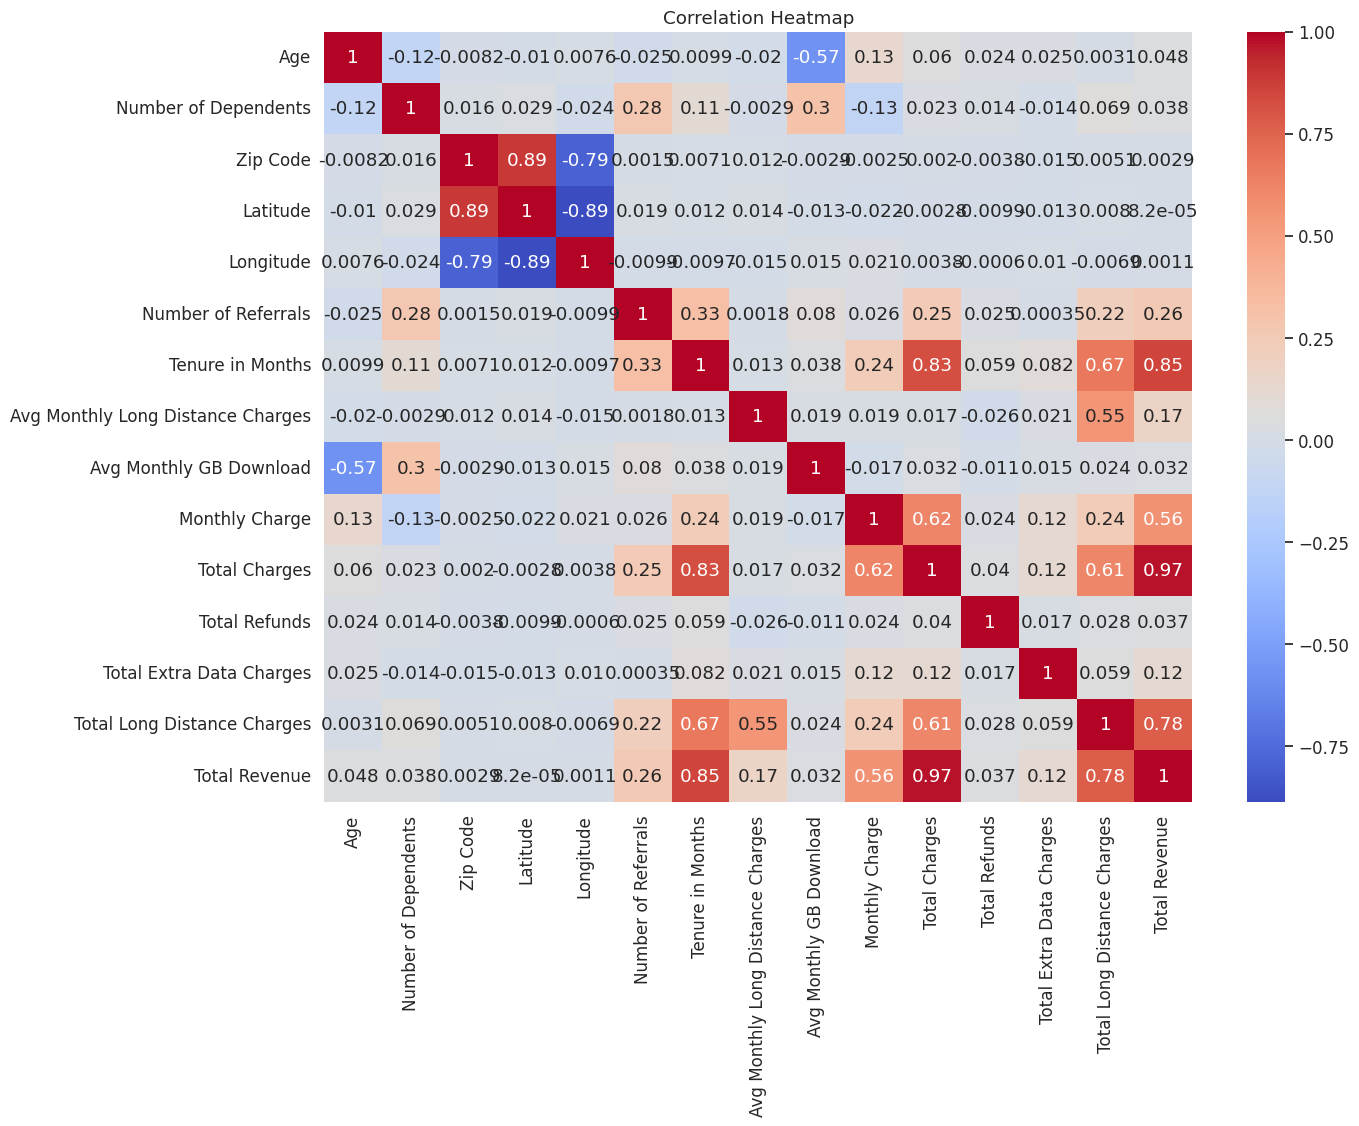

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(14,10))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

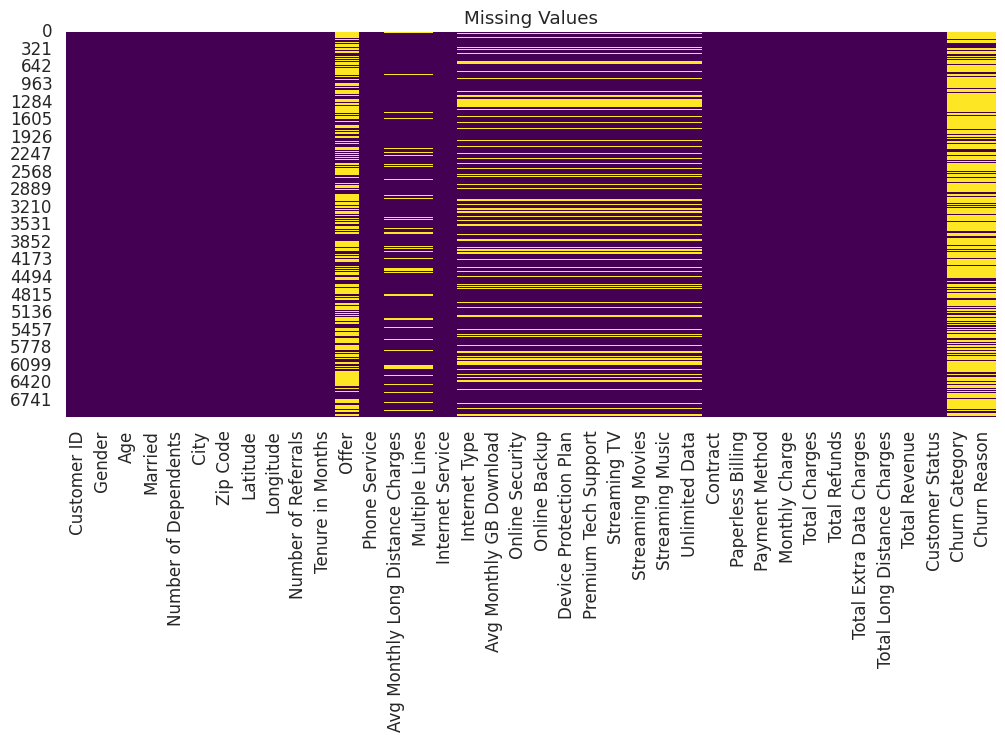

In [ ]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values")

plt.show()

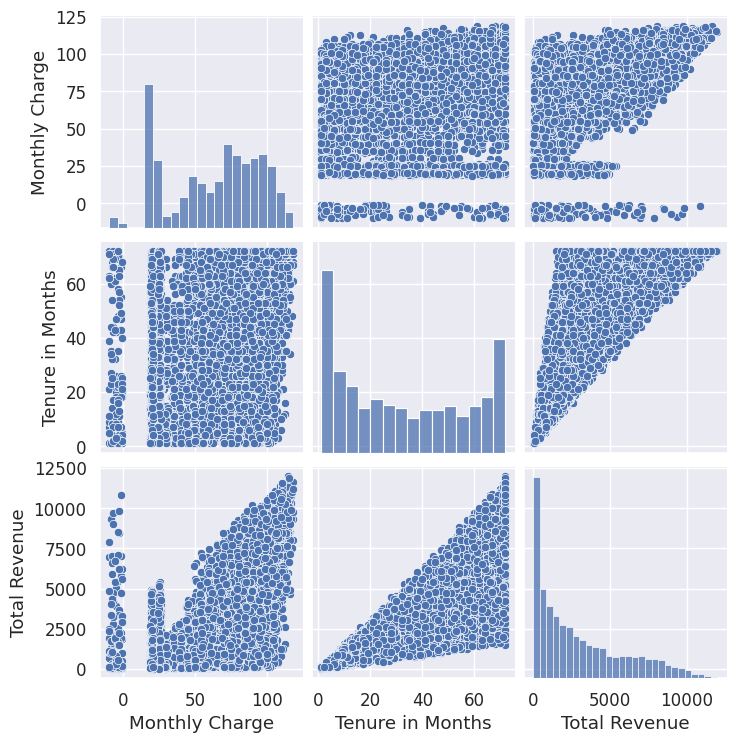

In [ ]:
sns.pairplot(
    df[['Monthly Charge',
        'Tenure in Months',
        'Total Revenue']]
)

plt.show()

In [ ]:
df.dtypes

,0
Customer ID,object
Gender,object
Age,int64
Married,object
Number of Dependents,int64
City,object
Zip Code,int64
Latitude,float64
Longitude,float64
Number of Referrals,int64


In [ ]:
if 'Customer ID' in df.columns:
    df.drop('Customer ID', axis=1, inplace=True)

print("Customer ID removed (if it existed).")

Customer ID removed (if it existed).


In [ ]:
if 'Total Charges' in df.columns:
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


In [ ]:
# Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical variables encoded.")

Categorical variables encoded.


In [ ]:
df.head()

,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0,37,1,0,346,93225,34.827662,-118.999073,2,9,...,1,65.6,593.30,0.00,0,381.51,974.81,2,1,2
1,1,46,0,0,368,91206,34.162515,-118.203869,0,9,...,1,-4.0,542.40,38.33,10,96.21,610.28,2,1,2
2,1,50,0,0,222,92627,33.645672,-117.922613,0,4,...,0,73.9,280.85,0.00,0,134.60,415.45,0,1,2
3,1,78,1,0,587,94553,38.014457,-122.115432,1,13,...,0,98.0,1237.85,0.00,0,361.66,1599.51,0,2,18
4,0,75,1,0,139,93010,34.227846,-119.079903,3,3,...,1,83.9,267.40,0.00,0,22.14,289.54,0,2,14


In [ ]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 36)
Target Shape : (7043,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (5634, 36)
Testing Samples : (1409, 36)


In [ ]:
print("Training Target Distribution:\n")
print(y_train.value_counts())

print("\nTesting Target Distribution:\n")
print(y_test.value_counts())

Training Target Distribution:

Customer Status
2    3776
0    1495
1     363
Name: count, dtype: int64

Testing Target Distribution:

Customer Status
2    944
0    374
1     91
Name: count, dtype: int64


In [ ]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (5634, 36)
X_test Shape  : (1409, 36)
y_train Shape : (5634,)
y_test Shape  : (1409,)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc*100,2),"%")

Logistic Regression Accuracy: 94.46 %


In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test,dt_pred)

print("Decision Tree Accuracy:",round(dt_acc*100,2),"%")

Decision Tree Accuracy: 95.6 %


In [ ]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy:",round(rf_acc*100,2),"%")

Random Forest Accuracy: 96.24 %


In [ ]:
# Gaussian Naive Bayes

nb = GaussianNB()

nb.fit(X_train,y_train)

nb_pred = nb.predict(X_test)

nb_acc = accuracy_score(y_test,nb_pred)

print("Gaussian Naive Bayes Accuracy:",round(nb_acc*100,2),"%")

Gaussian Naive Bayes Accuracy: 93.83 %


In [ ]:
# XGBoost

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test,xgb_pred)

print("XGBoost Accuracy:",round(xgb_acc*100,2),"%")

XGBoost Accuracy: 96.38 %


In [ ]:
accuracy = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gaussian Naive Bayes",
        "XGBoost"
    ],

    "Accuracy":[
        lr_acc,
        dt_acc,
        rf_acc,
        nb_acc,
        xgb_acc
    ]

})

accuracy["Accuracy"] = accuracy["Accuracy"]*100

accuracy = accuracy.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy

,Model,Accuracy
4,XGBoost,96.380412
2,Random Forest,96.238467
1,Decision Tree,95.599716
0,Logistic Regression,94.464159
3,Gaussian Naive Bayes,93.825408


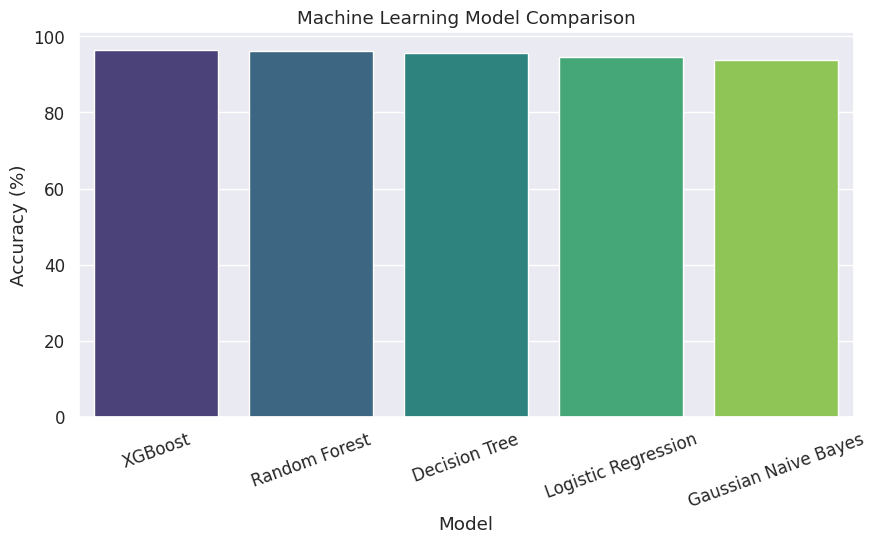

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=accuracy,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy (%)")

plt.title("Machine Learning Model Comparison")

plt.show()

In [ ]:
best_model = accuracy.iloc[0]

print("Best Model :",best_model["Model"])

print("Accuracy :",round(best_model["Accuracy"],2),"%")

Best Model : XGBoost
Accuracy : 96.38 %


In [ ]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       374
           1       0.89      0.93      0.91        91
           2       0.97      0.99      0.98       944

    accuracy                           0.96      1409
   macro avg       0.94      0.94      0.94      1409
weighted avg       0.96      0.96      0.96      1409



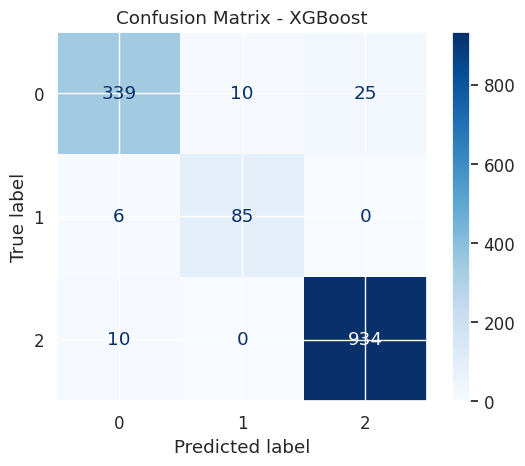

In [ ]:
cm = confusion_matrix(y_test,xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
35,Churn Reason,0.513455
34,Churn Category,0.188197
9,Tenure in Months,0.111696
25,Contract,0.038289
14,Internet Service,0.028025
17,Online Security,0.014338
8,Number of Referrals,0.011374
3,Number of Dependents,0.009805
20,Premium Tech Support,0.006072
30,Total Refunds,0.005963


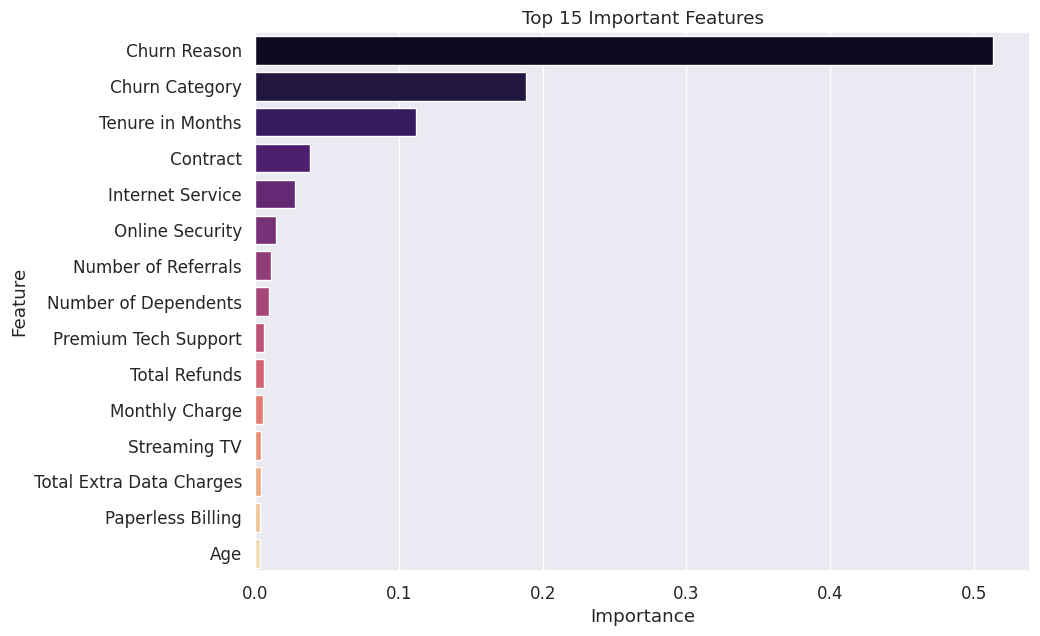

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=feature_importance.head(15),

    x="Importance",

    y="Feature",

    palette="magma"

)

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
import joblib

# Save the trained XGBoost model
joblib.dump(xgb, "customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
loaded_model = joblib.load("customer_churn_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
prediction = loaded_model.predict(X_test)

prediction[:10]

array([2, 0, 2, 0, 2, 1, 2, 0, 1, 2], dtype=int32)

In [ ]:
comparison = pd.DataFrame({

    "Actual": y_test.values,
    "Predicted": prediction

})

comparison.head(20)

,Actual,Predicted
0,2,2
1,0,0
2,2,2
3,0,0
4,2,2
5,1,1
6,2,2
7,0,0
8,0,1
9,2,2


In [ ]:
# Predict first customer in test dataset

sample = X_test[0].reshape(1, -1)

pred = loaded_model.predict(sample)

print("Predicted Customer Status:", pred[0])

Predicted Customer Status: 2


In [ ]:
status = {

    0: "Churned",
    1: "Joined",
    2: "Stayed"

}

print("Prediction :", status[pred[0]])

Prediction : Stayed


In [ ]:
print("Final Model Accuracy")

print(round(xgb_acc * 100,2),"%")

Final Model Accuracy
96.38 %


In [ ]:
accuracy.reset_index(drop=True)

,Model,Accuracy
0,XGBoost,96.380412
1,Random Forest,96.238467
2,Decision Tree,95.599716
3,Logistic Regression,94.464159
4,Gaussian Naive Bayes,93.825408


In [ ]:
print("="*50)

print("Customer Churn Prediction Project")

print("="*50)

print("Dataset Shape :",df.shape)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("Best Model :",best_model["Model"])

print("Accuracy :",round(best_model["Accuracy"],2),"%")

print("="*50)

Customer Churn Prediction Project
Dataset Shape : (7043, 37)
Training Samples : 5634
Testing Samples : 1409
Best Model : XGBoost
Accuracy : 96.38 %


In [ ]:
print("""
Conclusion
----------

✔ Customer churn prediction model developed successfully.

✔ Data preprocessing completed.

✔ Multiple Machine Learning models compared.

✔ XGBoost achieved the highest accuracy.

✔ Model saved for future deployment.

Project Completed Successfully!
""")


Conclusion
----------

✔ Customer churn prediction model developed successfully.

✔ Data preprocessing completed.

✔ Multiple Machine Learning models compared.

✔ XGBoost achieved the highest accuracy.

✔ Model saved for future deployment.

Project Completed Successfully!



In [ ]:
from google.colab import files

files.download("customer_churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>